In [11]:
# Import Library

import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

# Fungsi bantuan untuk menampilkan citra dan histogram berdampingan
def plot_image_and_hist(image, title="Citra"):
    hist = hitung_histogram(image)

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    axs[0].imshow(image, cmap='gray', vmin=0, vmax=255)
    axs[0].set_title(title)
    axs[0].axis('off')

    axs[1].bar(range(256), hist, color='black', width=1)
    axs[1].set_title(f"Histogram {title}")
    axs[1].set_xlim([0, 255])
    plt.show()

In [12]:
# Deklarasi fungsi-fungsi utama

def hitung_histogram(image):
    """Menghitung kemunculan tiap intensitas pixel (0-255)."""
    hist = np.zeros(256, dtype=int)
    N, M = image.shape
    for i in range(N):
        for j in range(M):
            nilai_pixel = image[i, j]
            hist[nilai_pixel] += 1
    return hist

def normalisasi_citra(image):
    """
    Melakukan Normalisasi Histogram (Contrast Stretching).
    Merentangkan nilai intensitas dari rentang (min, max) menjadi (0, 255).
    """
    N, M = image.shape
    r_min = np.min(image)
    r_max = np.max(image)

    # Buat array kosong untuk citra hasil normalisasi
    norm_image = np.zeros((N, M), dtype=np.uint8)

    for i in range(N):
        for j in range(M):
            # Rumus peregangan kontras: s = (r - r_min) / (r_max - r_min) * 255
            norm_val = ((image[i, j] - r_min) / (r_max - r_min)) * 255
            norm_image[i, j] = int(norm_val)

    return norm_image

def perataan_histogram(image):
    """
    Melakukan Histogram Equalization (Perataan Histogram)
    berdasarkan algoritma yang diberikan.
    """
    N, M = image.shape
    hist_count = hitung_histogram(image)

    # Hitung probabilitas tiap derajat keabuan: Pr(rk) = nk / n
    total_pixel = N * M
    Hist = [h / total_pixel for h in hist_count]

    HistEq = np.zeros(256, dtype=int)

    # Hitung kumulatif probabilitas dan petakan ke nilai baru (0-255)
    for i in range(256):
        total_sum = 0.0
        for j in range(i + 1):
            total_sum += Hist[j]
        HistEq[i] = math.floor(255 * total_sum)

    # Update citra sesuai histogram hasil perataan
    eq_image = np.zeros((N, M), dtype=np.uint8)
    for i in range(N):
        for j in range(M):
            eq_image[i][j] = HistEq[image[i][j]]

    return eq_image

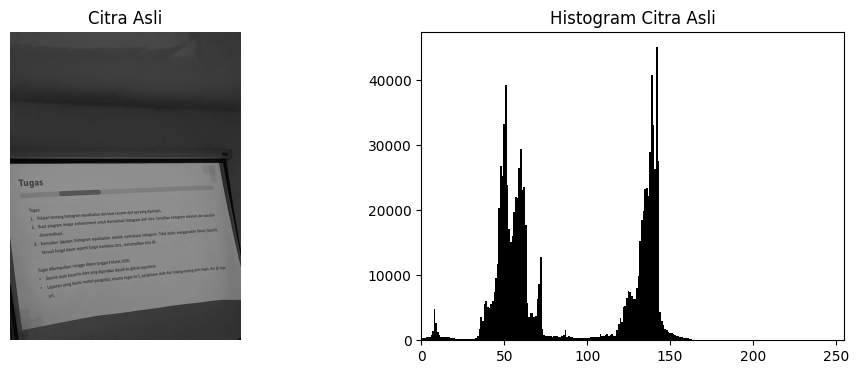

In [13]:
# Membaca citra dan menampilkan histogram asli

file_path = 'tugas.jpeg'
image_asli = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

if image_asli is None:
    print(f"Gagal membaca citra dari {file_path}. Pastikan file ada.")
else:
    # Tampilkan Citra Asli dan Histogramnya
    plot_image_and_hist(image_asli, title="Citra Asli")

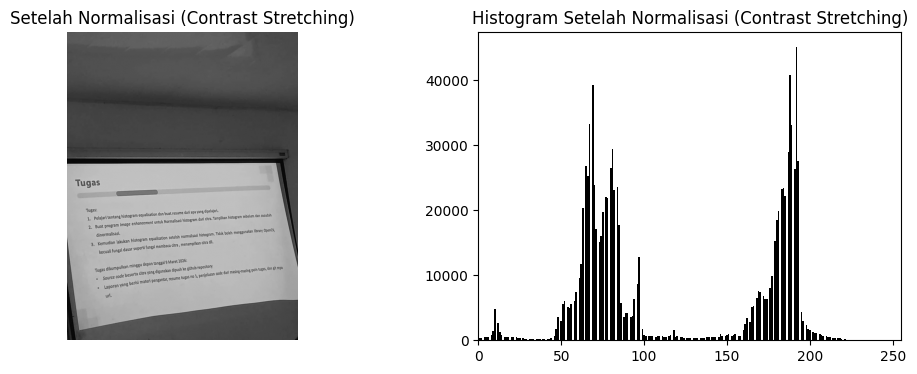

In [14]:
# Normalisasi histogram

if image_asli is not None:
    # 2. Lakukan normalisasi
    image_normalisasi = normalisasi_citra(image_asli)

    # Tampilkan Citra Hasil Normalisasi dan Histogramnya
    plot_image_and_hist(image_normalisasi, title="Setelah Normalisasi (Contrast Stretching)")

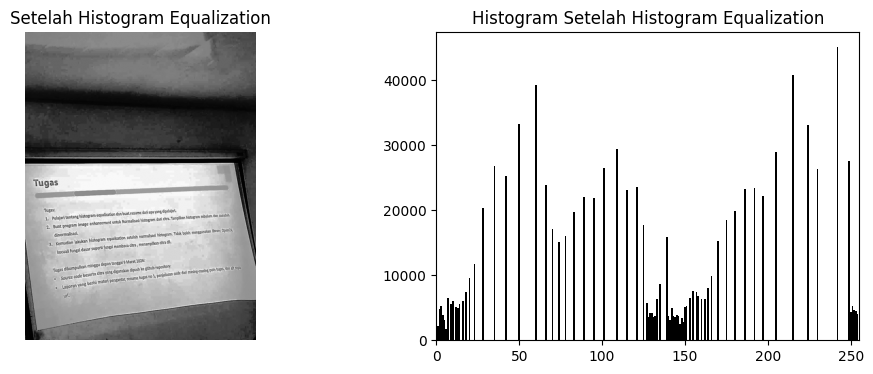

In [15]:
# Proses perataan histogram

if image_asli is not None:
    # 3. Lakukan Histogram Equalization setelah normalisasi
    image_equalization = perataan_histogram(image_normalisasi)

    # Tampilkan Citra Hasil Histogram Equalization dan Histogramnya
    plot_image_and_hist(image_equalization, title="Setelah Histogram Equalization")